In [62]:
import pandas as pd
import numpy as np
import yfinance as yf

def get_real_market_data():
    """
    Download real market data for regime detection.
    """

    print("Downloading real market data...")

    # Download ETFs and VIX
    spy = yf.download("SPY", start="2015-01-01")
    qqq = yf.download("QQQ", start="2015-01-01")
    tlt = yf.download("TLT", start="2015-01-01")
    gld = yf.download("GLD", start="2015-01-01")
    vix = yf.download("^VIX", start="2015-01-01")

    # Create feature dataframe
    features = pd.DataFrame(index=spy.index)

    # Market returns
    features['Returns'] = spy['Close'].pct_change()

    # Volatility proxy
    features['VIX'] = vix['Close'].pct_change()

    # Additional features
    features['QQQ_Returns'] = qqq['Close'].pct_change()
    features['TLT_Returns'] = tlt['Close'].pct_change()
    features['GLD_Returns'] = gld['Close'].pct_change()

    # Rolling volatility
    features['Rolling_Vol'] = features['Returns'].rolling(20).std()

    # Momentum
    features['Momentum'] = spy['Close'].pct_change(20)

    # Remove NaN values
    features = features.dropna()

    # Asset price for plotting
    raw_data = pd.DataFrame(index=features.index)

# Asset price
    raw_data['Asset'] = spy.loc[features.index, 'Close']

# Daily returns
    raw_data['Returns'] = features['Returns']
    

    print(f"Data downloaded successfully!")
    print(f"Total data points: {len(features)}")

    return raw_data, features

# Execute Step 1
raw_data, features = get_real_market_data()

print("\nFirst 5 rows of feature matrix:")
print(features.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!
Total data points: 2844

First 5 rows of feature matrix:
             Returns       VIX  QQQ_Returns  TLT_Returns  GLD_Returns  \
Date                                                                    
2015-02-02  0.012384 -0.073438     0.008704    -0.003776    -0.008343   
2015-02-03  0.014461 -0.108080     0.009610    -0.021166    -0.011191   
2015-02-04 -0.003808  0.057703    -0.000874     0.001709     0.004378   
2015-02-05  0.010095 -0.080742     0.008652    -0.010979     0.001727   
2015-02-06 -0.002765  0.026113    -0.006072    -0.017701    -0.025864   

            Rolling_Vol  Momentum  
Date                               
2015-02-02     0.011050 -0.017086  
2015-02-03     0.010767  0.015467  
2015-02-04     0.010557  0.021219  
2015-02-05     0.010435  0.018833  
2015-02-06     0.009682 -0.001700  


In [63]:
pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [64]:
from hmmlearn.hmm import GaussianHMM
import pandas as pd
import numpy as np

def train_market_regime_model(feature_matrix):
    """
    Train Hidden Markov Model (HMM) for market regime detection.
    """

    print("Training Hidden Markov Model for regime detection...")

    # Initialize HMM
    model = GaussianHMM(
        n_components=3,
        covariance_type="full",
        n_iter=200,
        random_state=42
    )

    # Train model
    model.fit(feature_matrix)

    # Predict hidden states
    hidden_states = model.predict(feature_matrix)

    print("Model training complete!")

    # Create analysis dataframe
    regime_analysis = pd.DataFrame({
        'State': hidden_states,
        'Returns': feature_matrix['Returns'],
        'VIX': feature_matrix['VIX']
    })

    # State statistics
    state_summary = regime_analysis.groupby('State').agg({
        'Returns': ['mean', 'std'],
        'VIX': ['mean', 'std']
    })

    print("\nMarket Regime Summary:")
    print(state_summary)

    # Professional regime labeling
    regime_labels = {}

    # Sort states by average returns
    sorted_states = state_summary[('Returns', 'mean')].sort_values()

    # Lowest return state = Crisis
    regime_labels[sorted_states.index[0]] = "Crisis"

    # Middle return state = Bear Market
    regime_labels[sorted_states.index[1]] = "Bear Market"

    # Highest return state = Bull Market
    regime_labels[sorted_states.index[2]] = "Bull Market"

    print("\nDetected Regimes:")

    for state, label in regime_labels.items():
        print(f"State {state} → {label}")

    # Return results
    return model, hidden_states, regime_labels


# Execute Step 2
hmm_model, states, regime_labels = train_market_regime_model(features)

Training Hidden Markov Model for regime detection...


Model is not converging.  Current: 62433.953776360286 is not greater than 62434.03663596127. Delta is -0.08285960098146461


Model training complete!

Market Regime Summary:
        Returns                 VIX          
           mean       std      mean       std
State                                        
0      0.001227  0.005719 -0.000401  0.057125
1     -0.001269  0.013190  0.015917  0.131637
2      0.001300  0.021497 -0.004610  0.084061

Detected Regimes:
State 1 → Crisis
State 0 → Bear Market
State 2 → Bull Market


Generating market regime visualization...


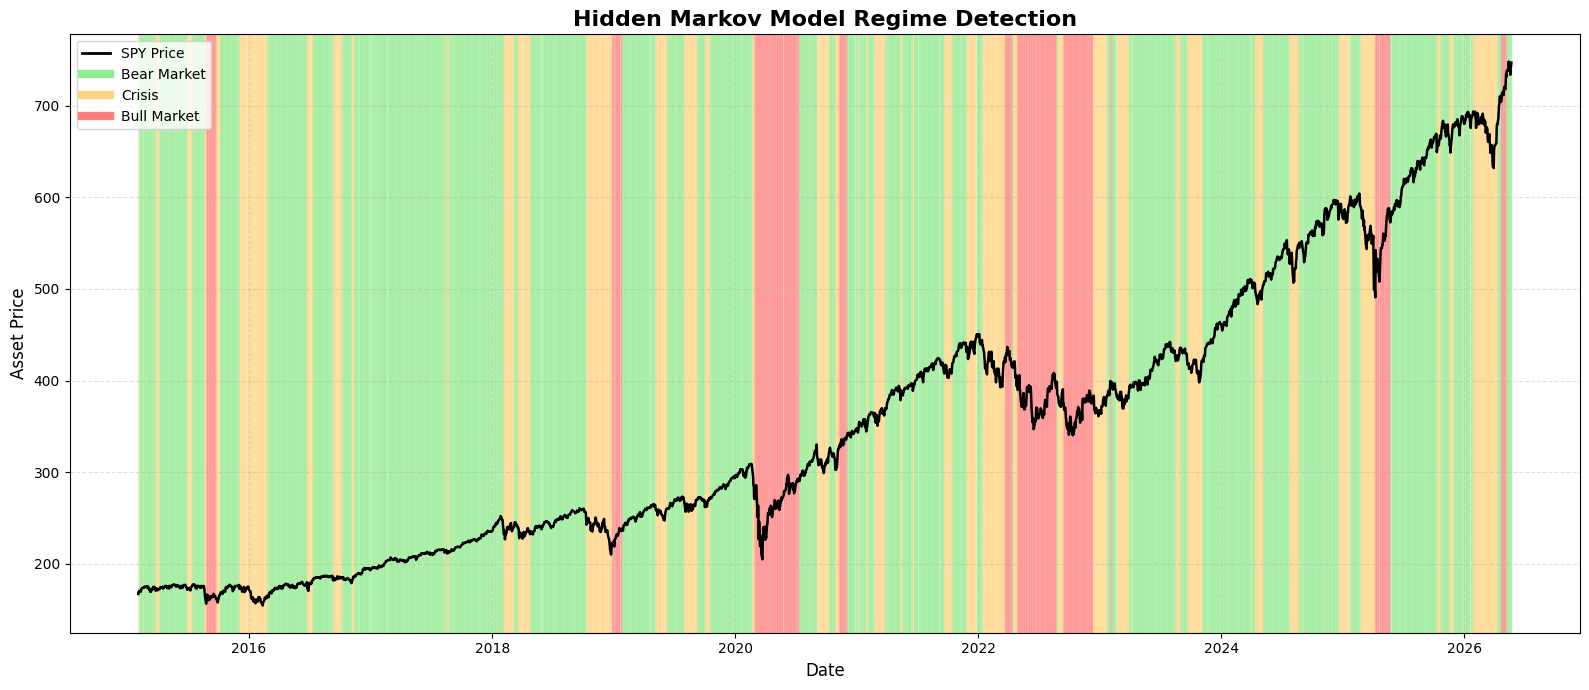

In [65]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_market_regimes(raw_data, hidden_states, regime_labels):
    """
    Visualize market regimes identified by the HMM model.
    """

    print("Generating market regime visualization...")

    plt.figure(figsize=(16, 7))

    # Plot asset price
    plt.plot(
        raw_data.index,
        raw_data['Asset'],
        color='black',
        linewidth=1.8,
        label='SPY Price'
    )

    # Professional color palette
    state_colors = {
        0: '#90EE90',  # light green
        1: '#FFD580',  # light orange
        2: '#FF7F7F'   # light red
    }

    # Background regime shading
    for i in range(len(raw_data) - 1):

        plt.axvspan(
            raw_data.index[i],
            raw_data.index[i + 1],
            color=state_colors[hidden_states[i]],
            alpha=0.25
        )

    # Custom legend
    custom_lines = [
        Line2D([0], [0], color='black', lw=2),

        Line2D([0], [0],
               color=state_colors[0],
               lw=6),

        Line2D([0], [0],
               color=state_colors[1],
               lw=6),

        Line2D([0], [0],
               color=state_colors[2],
               lw=6)
    ]

    legend_labels = [
        'SPY Price',
        regime_labels.get(0, 'State 0'),
        regime_labels.get(1, 'State 1'),
        regime_labels.get(2, 'State 2')
    ]

    plt.legend(
        custom_lines,
        legend_labels,
        loc='upper left'
    )

    plt.title(
        "Hidden Markov Model Regime Detection",
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Asset Price", fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# Execute Step 3
plot_market_regimes(raw_data, states, regime_labels)

In [66]:
pip install cvxpy

Note: you may need to restart the kernel to use updated packages.


In [67]:
import cvxpy as cp
import numpy as np
import pandas as pd

def optimize_portfolio_by_regime(hidden_states, regime_labels, raw_data):
    """
    Dynamic portfolio allocation based on detected market regimes.
    """

    print("Generating regime-aware portfolio allocation...")

    weights_df = pd.DataFrame(index=raw_data.index)

    stock_weights = []

    for state in hidden_states:

        regime = regime_labels[state]

        # Aggressive allocation during bull markets
        if regime == "Bull Market":
            stock_weights.append(0.90)

        # Moderate defensive positioning
        elif regime == "Bear Market":
            stock_weights.append(0.50)

        # Capital preservation during crisis
        elif regime == "Crisis":
            stock_weights.append(0.10)

    weights_df['Stock_Weight'] = stock_weights
    weights_df['Cash_Weight'] = 1 - weights_df['Stock_Weight']

    print("Portfolio allocation complete!")

    return weights_df


# Execute Step 4
portfolio_weights = optimize_portfolio_by_regime(
    states,
    regime_labels,
    raw_data
)

print(portfolio_weights.head())

Generating regime-aware portfolio allocation...
Portfolio allocation complete!
            Stock_Weight  Cash_Weight
Date                                 
2015-02-02           0.1          0.9
2015-02-03           0.1          0.9
2015-02-04           0.5          0.5
2015-02-05           0.5          0.5
2015-02-06           0.5          0.5


Running transaction-cost-aware portfolio backtest...


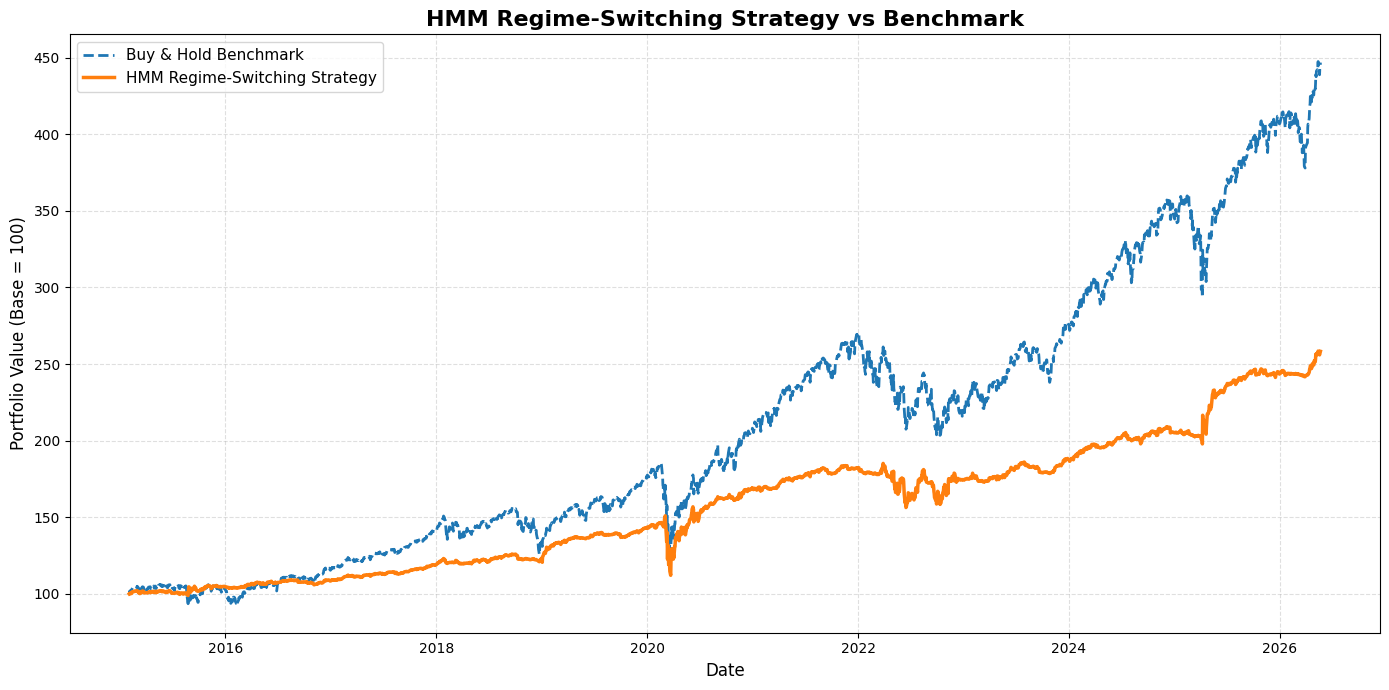


Strategy Total Return: 158.31%


In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def run_final_backtest(raw_data, weights_df, transaction_cost_bps=10):
    """
    Run a transaction-cost-aware regime-switching portfolio backtest.
    """

    print("Running transaction-cost-aware portfolio backtest...")

    # Daily market returns
    asset_returns = raw_data['Returns'].values

    # Portfolio weights
    stock_weights = weights_df['Stock_Weight'].values

    # Portfolio tracking arrays
    portfolio_returns = np.zeros(len(raw_data))
    portfolio_value = np.zeros(len(raw_data))

    # Initial capital
    portfolio_value[0] = 100

    # Transaction cost factor
    cost_factor = transaction_cost_bps / 10000

    # Backtest loop
    for t in range(1, len(raw_data)):

        # Strategy return
        raw_strategy_return = (
            stock_weights[t - 1] * asset_returns[t]
        )

        # Portfolio turnover
        weight_change = abs(
            stock_weights[t] - stock_weights[t - 1]
        )

        # Transaction fees
        fees = weight_change * cost_factor

        # Net return after fees
        portfolio_returns[t] = (
            raw_strategy_return - fees
        )

        # Portfolio equity curve
        portfolio_value[t] = (
            portfolio_value[t - 1] *
            (1 + portfolio_returns[t])
        )

    # Results dataframe
    results_df = pd.DataFrame(index=raw_data.index)

    # Benchmark
    results_df['Benchmark'] = (
        100 *
        (raw_data['Asset'] /
         raw_data['Asset'].iloc[0])
    )

    # Strategy
    results_df['HMM Regime Strategy'] = portfolio_value

    # ===============================
    # Plot Equity Curve
    # ===============================

    plt.figure(figsize=(14, 7))

    plt.plot(
        results_df.index,
        results_df['Benchmark'],
        label='Buy & Hold Benchmark',
        linestyle='--',
        linewidth=2
    )

    plt.plot(
        results_df.index,
        results_df['HMM Regime Strategy'],
        label='HMM Regime-Switching Strategy',
        linewidth=2.5
    )

    plt.title(
        "HMM Regime-Switching Strategy vs Benchmark",
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel("Date", fontsize=12)

    plt.ylabel(
        "Portfolio Value (Base = 100)",
        fontsize=12
    )

    plt.legend(fontsize=11)

    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()

    plt.show()

    # Final return
    total_return = (
        portfolio_value[-1] / 100
    ) - 1

    print(
        f"\nStrategy Total Return: "
        f"{total_return * 100:.2f}%"
    )

    return results_df


# Execute Step 5
final_results = run_final_backtest(
    raw_data,
    portfolio_weights
)

In [69]:
def evaluate_strategy_performance(results_df, risk_free_rate=0.05):
    """
    Generate institutional-grade portfolio performance metrics.
    """

    print("\n" + "=" * 60)

    print(
        "     HMM REGIME-SWITCHING STRATEGY PERFORMANCE REPORT"
    )

    print("=" * 60)

    performance_data = {}

    trading_days = 252

    for column in [
        'Benchmark',
        'HMM Regime Strategy'
    ]:

        # Initial and final values
        initial_val = results_df[column].iloc[0]

        final_val = results_df[column].iloc[-1]

        # Daily returns
        daily_returns = (
            results_df[column]
            .pct_change()
            .dropna()
        )

        # Cumulative return
        cumulative_return = (
            final_val / initial_val
        ) - 1

        # CAGR
        annualized_return = (
            (final_val / initial_val)
            ** (trading_days / len(results_df))
        ) - 1

        cagr = annualized_return

        # Annualized volatility
        annualized_volatility = (
            daily_returns.std()
            * np.sqrt(trading_days)
        )

        # Sharpe ratio
        sharpe_ratio = (
            (annualized_return - risk_free_rate)
            / annualized_volatility
            if annualized_volatility != 0 else 0
        )

        # Sortino ratio
        downside_returns = (
            daily_returns[daily_returns < 0]
        )

        downside_std = (
            downside_returns.std()
            * np.sqrt(trading_days)
        )

        sortino_ratio = (
            (annualized_return - risk_free_rate)
            / downside_std
            if downside_std != 0 else 0
        )

        # Maximum drawdown
        rolling_max = (
            results_df[column].cummax()
        )

        drawdowns = (
            (results_df[column] - rolling_max)
            / rolling_max
        )

        max_drawdown = drawdowns.min()

        # Store metrics
        performance_data[column] = {

            "Cumulative Return":
                f"{cumulative_return * 100:.2f}%",

            "CAGR":
                f"{cagr * 100:.2f}%",

            "Annualized Volatility":
                f"{annualized_volatility * 100:.2f}%",

            "Sharpe Ratio":
                f"{sharpe_ratio:.2f}",

            "Sortino Ratio":
                f"{sortino_ratio:.2f}",

            "Maximum Drawdown":
                f"{max_drawdown * 100:.2f}%"
        }

    # Performance matrix
    performance_matrix = pd.DataFrame(
        performance_data
    )

    print(performance_matrix)

    print("=" * 60)

    return performance_matrix


# Execute Step 6
performance_matrix = evaluate_strategy_performance(
    final_results
)


     HMM REGIME-SWITCHING STRATEGY PERFORMANCE REPORT
                      Benchmark HMM Regime Strategy
Cumulative Return       346.75%             158.31%
CAGR                     14.18%               8.77%
Annualized Volatility    17.67%              11.48%
Sharpe Ratio               0.52                0.33
Sortino Ratio              0.63                0.36
Maximum Drawdown        -33.72%             -25.72%
